<a href="https://colab.research.google.com/github/vishhhsurya/Data-science/blob/main/Ecommerce_Product_Recommendation_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# E-COMMERCE — WHAT SHOULD WE RECOMMEND TO CUSTOMERS?

**Industry:** E-Commerce

This notebook cleans customer-product data, analyses customer preferences and product associations, calculates support, confidence and lift, creates four visualisations, and builds/evaluates a KNN recommendation model.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import NearestNeighbors
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


## 2. Load Dataset

In [2]:
from google.colab import files
uploaded = files.upload()
file_name = next(iter(uploaded))
df = pd.read_csv(file_name)
print("Dataset loaded successfully.")
print("Shape:", df.shape)
df.head()


Saving ecommerce_customer_product_data (1).csv to ecommerce_customer_product_data (1).csv
Dataset loaded successfully.
Shape: (992, 8)


,Customer_ID,Product_ID,Product_Name,Product_Category,Purchase_History,Rating,Browse_Count,Browsing_Behaviour
0,C047,P018,Wallet,Bags,3,4.0,5,Medium
1,C074,P022,Hoodie,Fashion,1,5.0,4,Medium
2,C113,P034,Novel,Books,1,4.0,9,High
3,C069,P009,Keyboard,Accessories,2,3.8,6,High
4,C022,P015,Sports T-Shirt,Sports,1,4.1,6,High


## 3. Dataset Overview

In [3]:
print("Dataset Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nData Types:")
print(df.dtypes)
display(df.head())


Dataset Shape: (992, 8)
Columns: ['Customer_ID', 'Product_ID', 'Product_Name', 'Product_Category', 'Purchase_History', 'Rating', 'Browse_Count', 'Browsing_Behaviour']

Data Types:
Customer_ID            object
Product_ID             object
Product_Name           object
Product_Category       object
Purchase_History        int64
Rating                float64
Browse_Count            int64
Browsing_Behaviour     object
dtype: object


,Customer_ID,Product_ID,Product_Name,Product_Category,Purchase_History,Rating,Browse_Count,Browsing_Behaviour
0,C047,P018,Wallet,Bags,3,4.0,5,Medium
1,C074,P022,Hoodie,Fashion,1,5.0,4,Medium
2,C113,P034,Novel,Books,1,4.0,9,High
3,C069,P009,Keyboard,Accessories,2,3.8,6,High
4,C022,P015,Sports T-Shirt,Sports,1,4.1,6,High


## 4. Data Cleaning and Validation

In [4]:
print("Missing values:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
df["Purchase_History"]=pd.to_numeric(df["Purchase_History"],errors="coerce")
df["Rating"]=pd.to_numeric(df["Rating"],errors="coerce")
df["Browse_Count"]=pd.to_numeric(df["Browse_Count"],errors="coerce")
print("Invalid ratings:",((df["Rating"]<1)|(df["Rating"]>5)).sum())
print("Negative purchase values:",(df["Purchase_History"]<0).sum())
print("Negative browse values:",(df["Browse_Count"]<0).sum())
df=df.dropna().drop_duplicates().reset_index(drop=True)
print("Final dataset shape:",df.shape)


Missing values:
Customer_ID           0
Product_ID            0
Product_Name          0
Product_Category      0
Purchase_History      0
Rating                0
Browse_Count          0
Browsing_Behaviour    0
dtype: int64

Duplicate rows: 0
Invalid ratings: 0
Negative purchase values: 0
Negative browse values: 0
Final dataset shape: (992, 8)


## 5. Descriptive Statistics

In [5]:
display(df[["Purchase_History","Rating","Browse_Count"]].describe())
print("Unique customers:",df.Customer_ID.nunique())
print("Unique products:",df.Product_ID.nunique())
print("Categories:",df.Product_Category.nunique())


,Purchase_History,Rating,Browse_Count
count,992.000000,992.000000,992.000000
mean,1.341734,4.088105,5.872984
std,0.553087,0.606074,2.159623
min,1.000000,2.200000,1.000000
25%,1.000000,3.700000,4.000000
50%,1.000000,4.100000,6.000000
75%,2.000000,4.600000,7.000000
max,3.000000,5.000000,15.000000


Unique customers: 220
Unique products: 29
Categories: 8


## 6. Customer Preferences

In [6]:
product_summary=df.groupby(["Product_ID","Product_Name","Product_Category"]).agg(
Customers=("Customer_ID","nunique"),Total_Purchases=("Purchase_History","sum"),
Avg_Rating=("Rating","mean"),Avg_Browse_Count=("Browse_Count","mean")
).sort_values("Total_Purchases",ascending=False)
display(product_summary.head(10))
category_summary=df.groupby("Product_Category").agg(
Customers=("Customer_ID","nunique"),Total_Purchases=("Purchase_History","sum"),
Avg_Rating=("Rating","mean"),Avg_Browse_Count=("Browse_Count","mean")
).sort_values("Total_Purchases",ascending=False)
display(category_summary)


,,,Customers,Total_Purchases,Avg_Rating,Avg_Browse_Count
Product_ID,Product_Name,Product_Category,,,,
P016,Backpack,Bags,66,90,4.225758,6.378788
P006,Laptop Stand,Electronics,49,70,4.079592,5.816327
P022,Hoodie,Fashion,42,63,4.223810,6.071429
P019,Sunglasses,Fashion,44,61,4.004545,5.659091
P018,Wallet,Bags,42,59,4.007143,5.380952
P021,Jeans,Fashion,41,56,3.997561,5.878049
P020,Casual Shirt,Fashion,43,54,4.146512,6.348837
P011,Running Shoes,Sports,35,50,3.965714,5.914286
P001,Wireless Headphones,Electronics,35,50,4.165714,5.914286


,Customers,Total_Purchases,Avg_Rating,Avg_Browse_Count
Product_Category,,,,
Electronics,70,261,4.120305,5.898477
Fashion,54,234,4.092941,5.988235
Sports,45,225,4.045977,5.804598
Home,42,185,4.105755,6.208633
Bags,108,149,4.140741,5.990741
Accessories,44,114,4.019767,5.604651
Stationery,29,89,4.026154,5.692308
Books,30,74,4.124528,5.169811


## 7. Frequently Purchased Products

In [7]:
top_products=df.groupby(["Product_ID","Product_Name"])["Purchase_History"].sum().sort_values(ascending=False).head(10)
display(top_products.reset_index(name="Total_Purchases"))


,Product_ID,Product_Name,Total_Purchases
0,P016,Backpack,90
1,P006,Laptop Stand,70
2,P022,Hoodie,63
3,P019,Sunglasses,61
4,P018,Wallet,59
5,P021,Jeans,56
6,P020,Casual Shirt,54
7,P011,Running Shoes,50
8,P001,Wireless Headphones,50
9,P028,Water Bottle Set,49


## 8. Product Associations — Support, Confidence and Lift

In [8]:
transactions=df.groupby("Customer_ID")["Product_ID"].apply(set)
product_ids=sorted(df.Product_ID.unique()); n_transactions=len(transactions)
support={p:sum(p in items for items in transactions)/n_transactions for p in product_ids}
rules=[]
for i,p1 in enumerate(product_ids):
    for p2 in product_ids[i+1:]:
        both=sum((p1 in items) and (p2 in items) for items in transactions)
        if both==0: continue
        ps=both/n_transactions
        c1=ps/support[p1]; c2=ps/support[p2]
        lift=ps/(support[p1]*support[p2])
        rules.append([p1,p2,ps,c1,c2,lift])
rules_df=pd.DataFrame(rules,columns=["Product_A","Product_B","Support","Confidence_A_to_B","Confidence_B_to_A","Lift"]).sort_values("Lift",ascending=False)
display(rules_df.head(10))


,Product_A,Product_B,Support,Confidence_A_to_B,Confidence_B_to_A,Lift
76,P031,P032,0.072727,0.800000,0.761905,8.380952
79,P031,P035,0.086364,0.950000,0.703704,7.740741
80,P032,P033,0.077273,0.809524,0.708333,7.420635
77,P031,P033,0.072727,0.800000,0.666667,7.333333
85,P034,P035,0.104545,0.884615,0.851852,7.207977
78,P031,P034,0.077273,0.850000,0.653846,7.192308
83,P033,P034,0.090909,0.833333,0.769231,7.051282
82,P032,P035,0.081818,0.857143,0.666667,6.984127
81,P032,P034,0.077273,0.809524,0.653846,6.849817
84,P033,P035,0.090909,0.833333,0.740741,6.790123


## 9. Strong Recommendation Rules

In [9]:
strong_rules=rules_df[(rules_df.Support>=0.05)&((rules_df.Confidence_A_to_B>=0.30)|(rules_df.Confidence_B_to_A>=0.30))&(rules_df.Lift>1)]
print("Strong rules found:",len(strong_rules))
display(strong_rules.head(15))


Strong rules found: 86


,Product_A,Product_B,Support,Confidence_A_to_B,Confidence_B_to_A,Lift
76,P031,P032,0.072727,0.800000,0.761905,8.380952
79,P031,P035,0.086364,0.950000,0.703704,7.740741
80,P032,P033,0.077273,0.809524,0.708333,7.420635
77,P031,P033,0.072727,0.800000,0.666667,7.333333
85,P034,P035,0.104545,0.884615,0.851852,7.207977
78,P031,P034,0.077273,0.850000,0.653846,7.192308
83,P033,P034,0.090909,0.833333,0.769231,7.051282
82,P032,P035,0.081818,0.857143,0.666667,6.984127
81,P032,P034,0.077273,0.809524,0.653846,6.849817
84,P033,P035,0.090909,0.833333,0.740741,6.790123


## 10. Visualisation 1 — Top Purchased Products

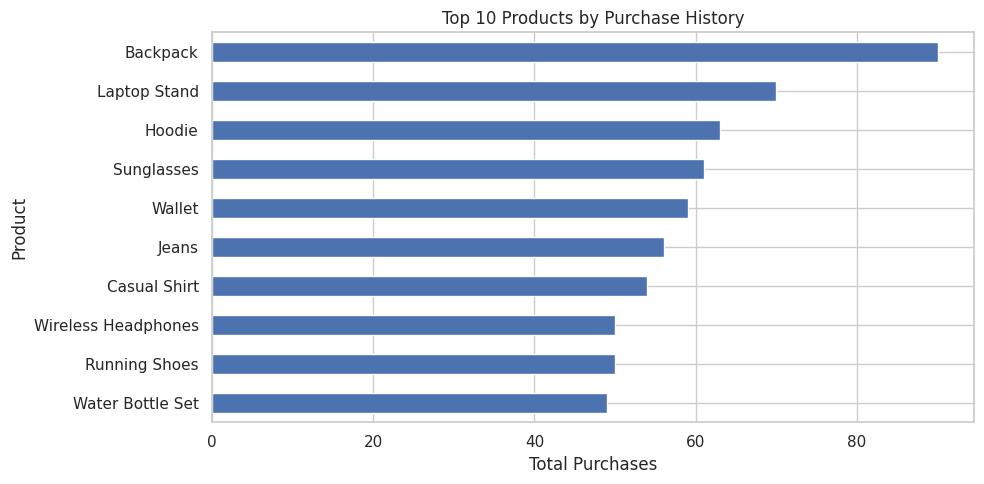

In [10]:
top10=df.groupby("Product_Name")["Purchase_History"].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5)); top10.sort_values().plot(kind="barh")
plt.title("Top 10 Products by Purchase History"); plt.xlabel("Total Purchases"); plt.ylabel("Product"); plt.tight_layout(); plt.show()


## 11. Visualisation 2 — Purchases by Category

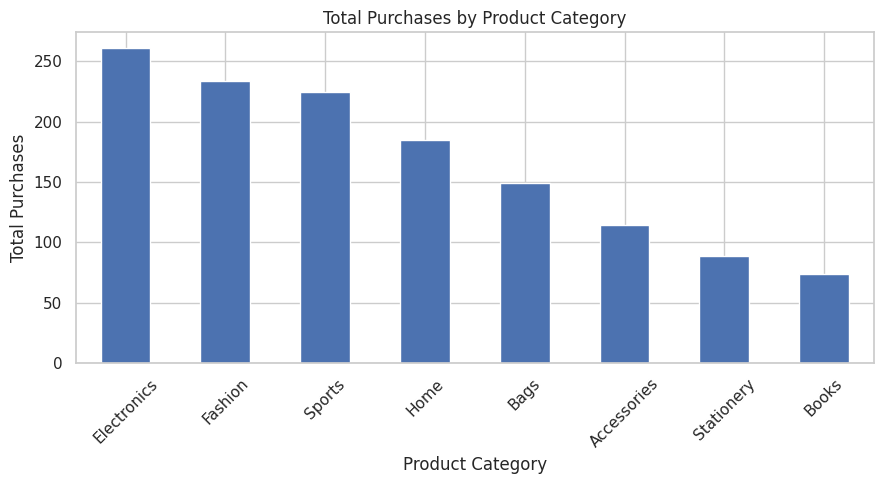

In [11]:
cat=df.groupby("Product_Category")["Purchase_History"].sum().sort_values(ascending=False)
plt.figure(figsize=(9,5)); cat.plot(kind="bar")
plt.title("Total Purchases by Product Category"); plt.xlabel("Product Category"); plt.ylabel("Total Purchases")
plt.xticks(rotation=45); plt.tight_layout(); plt.show()


## 12. Visualisation 3 — Browsing vs Rating

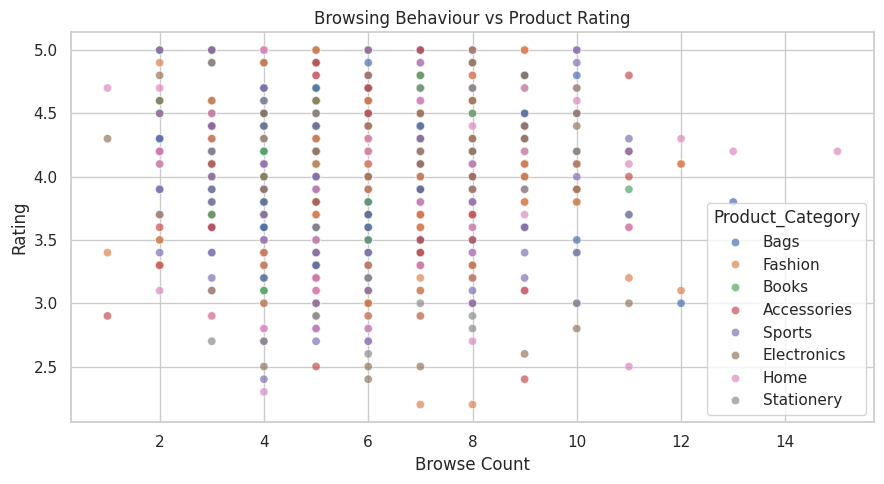

In [12]:
plt.figure(figsize=(9,5))
sns.scatterplot(data=df,x="Browse_Count",y="Rating",hue="Product_Category",alpha=.7)
plt.title("Browsing Behaviour vs Product Rating"); plt.xlabel("Browse Count"); plt.ylabel("Rating")
plt.tight_layout(); plt.show()


## 13. Visualisation 4 — Association Heatmap

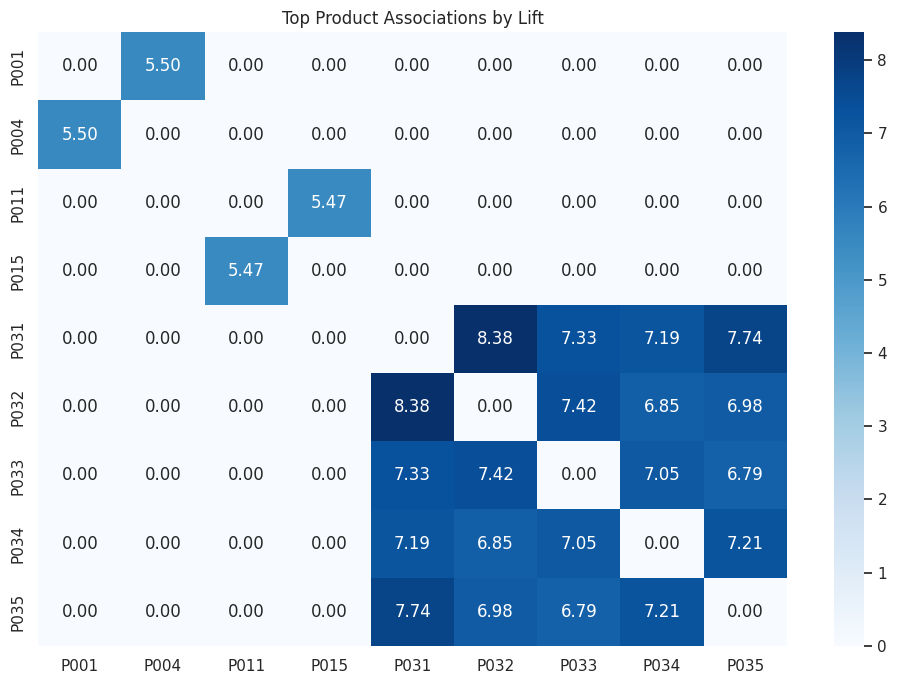

In [13]:
top_assoc=rules_df.head(12)
labels=sorted(set(top_assoc.Product_A)|set(top_assoc.Product_B))
mat=pd.DataFrame(0.0,index=labels,columns=labels)
for _,r in top_assoc.iterrows():
    mat.loc[r.Product_A,r.Product_B]=r.Lift; mat.loc[r.Product_B,r.Product_A]=r.Lift
plt.figure(figsize=(10,7)); sns.heatmap(mat,annot=True,fmt=".2f",cmap="Blues")
plt.title("Top Product Associations by Lift"); plt.tight_layout(); plt.show()


## 14. Prepare Customer-Product Matrix

In [14]:
customer_product=pd.pivot_table(df,index="Customer_ID",columns="Product_ID",values="Purchase_History",aggfunc="sum",fill_value=0)
interaction_matrix=(customer_product>0).astype(int)
print("Customer-product matrix shape:",interaction_matrix.shape)
display(interaction_matrix.head())


Customer-product matrix shape: (220, 29)


Product_ID,P001,P002,P003,P004,P005,P006,P008,P009,P010,P011,P012,P013,P014,P015,P016,P018,P019,P020,P021,P022,P027,P028,P029,P030,P031,P032,P033,P034,P035
Customer_ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
C001,0,0,0,0,0,0,0,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
C002,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1
C003,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0
C004,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,0,0,0,0,0,0,0,0,0
C005,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,0,0,0,0,0,0,0,0,0,0


## 15. Train KNN Model

In [15]:
knn=NearestNeighbors(metric="cosine",algorithm="brute",n_neighbors=6)
knn.fit(interaction_matrix)
print("KNN model trained successfully.")


KNN model trained successfully.


In [18]:
pdf = df[["Product_ID", "Product_Name", "Product_Category"]].drop_duplicates()

print("Product lookup created successfully.")
display(pdf.head())

Product lookup created successfully.


,Product_ID,Product_Name,Product_Category
0,P018,Wallet,Bags
1,P022,Hoodie,Fashion
2,P034,Novel,Books
3,P009,Keyboard,Accessories
4,P015,Sports T-Shirt,Sports


## 16. Generate Recommendations

In [19]:
def recommend_products(customer_id,n_recommendations=5):
    if customer_id not in interaction_matrix.index: return pd.DataFrame()
    vector=interaction_matrix.loc[[customer_id]]
    distances,indices=knn.kneighbors(vector)
    neighbors=interaction_matrix.iloc[indices[0][1:]]
    scores=neighbors.sum(axis=0).sort_values(ascending=False)
    already=set(interaction_matrix.loc[customer_id][interaction_matrix.loc[customer_id]>0].index)
    rec=scores[~scores.index.isin(already)].head(n_recommendations).reset_index()
    rec.columns=["Product_ID","Recommendation_Score"]
    return rec.merge(pdf,on="Product_ID")[["Product_ID","Product_Name","Product_Category","Recommendation_Score"]]
sample_customer=interaction_matrix.index[0]
print("Recommendations for:",sample_customer)
display(recommend_products(sample_customer))


Recommendations for: C001


,Product_ID,Product_Name,Product_Category,Recommendation_Score
0,P011,Running Shoes,Sports,4
1,P013,Water Bottle,Sports,4
2,P015,Sports T-Shirt,Sports,3
3,P004,USB-C Charger,Electronics,0
4,P005,Power Bank,Electronics,0


## 17. KNN Evaluation — Hit Rate@5

In [21]:
hits=0; tests=0
for customer_id in interaction_matrix.index:
    purchased=list(interaction_matrix.loc[customer_id][interaction_matrix.loc[customer_id]>0].index)
    if len(purchased)<2: continue
    hidden=purchased[0]
    modified=interaction_matrix.loc[[customer_id]].copy(); modified.loc[customer_id,hidden]=0
    _,indices=knn.kneighbors(modified,n_neighbors=6)
    neighbors=interaction_matrix.iloc[indices[0][1:]]
    recs=list(neighbors.sum(axis=0).sort_values(ascending=False).head(5).index)
    hits+=int(hidden in recs); tests+=1
hit_rate=hits/tests if tests else 0
print("Evaluation tests:",tests)
print("Hits:",hits)
print(f"Hit Rate@5: {hit_rate:.3f}")
print(f"Hit Rate@5 (%): {hit_rate*100:.2f}%")


Evaluation tests: 220
Hits: 190
Hit Rate@5: 0.864
Hit Rate@5 (%): 86.36%


## 18. Key Insights

In [22]:
top_product=df.groupby("Product_Name")["Purchase_History"].sum().idxmax()
top_category=df.groupby("Product_Category")["Purchase_History"].sum().idxmax()
best=rules_df.iloc[0]
print("KEY INSIGHTS")
print(f"1. Most purchased product: {top_product}.")
print(f"2. Highest-purchase category: {top_category}.")
print(f"3. Average rating: {df.Rating.mean():.2f}/5.")
print(f"4. Average browsing count: {df.Browse_Count.mean():.2f}.")
print(f"5. Strongest association by lift: {best.Product_A} + {best.Product_B}, Lift={best.Lift:.2f}.")
print(f"6. KNN Hit Rate@5: {hit_rate*100:.2f}%.")
print("7. Similar-customer recommendations can be combined with association rules for cross-selling.")


KEY INSIGHTS
1. Most purchased product: Backpack.
2. Highest-purchase category: Electronics.
3. Average rating: 4.09/5.
4. Average browsing count: 5.87.
5. Strongest association by lift: P031 + P032, Lift=8.38.
6. KNN Hit Rate@5: 86.36%.
7. Similar-customer recommendations can be combined with association rules for cross-selling.


## 19. Practical Action Plan
1. Recommend products bought by customers with similar purchase patterns.
2. Use high-lift product pairs in Frequently Bought Together sections.
3. Promote high-demand categories based on purchase history.
4. Use browsing behaviour as an additional recommendation signal.
5. Review frequently viewed but lower-rated products.
6. Update the recommendation model as new customer interactions arrive.

## 20. Conclusion
The analysis identifies customer preferences and product relationships using descriptive statistics and association metrics. Support measures how often products occur together, confidence measures the conditional relationship, and lift compares the observed relationship with what would be expected by chance. KNN provides an interpretable recommendation approach based on similar customer purchase patterns.